# Procedimiento

In [121]:
import zipfile
import os
import shutil

zip_file_path = '/content/fruits_dataset_balanced.zip'
extraction_path = '/content/fruits_dataset'

# Remove the file path if exists
if os.path.exists(extraction_path):
    shutil.rmtree(extraction_path)
    print(f"Existing directory '{extraction_path}' deleted.")
os.makedirs(extraction_path, exist_ok=True)

# Unzip the ZIP file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Extracted files to: {extraction_path}")

Existing directory '/content/fruits_dataset' deleted.
Extracted files to: /content/fruits_dataset


In [122]:
# Import all the libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras import models
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [123]:
# Define paths for the dataset and its subsets
DATASET_PATH = "/content/fruits_dataset"
TRAINING_PATH = DATASET_PATH + "/Training"
TEST_PATH = DATASET_PATH + "/Test"
VALIDATION_PATH = DATASET_PATH + "/Validation"

In [124]:
# Define parameters
EPOCHS = 25
classes = os.listdir(TRAINING_PATH)
INPUT_SHAPE = (256, 256, 3)

## Hiperparametros utilizados

In [125]:
# Define hyperparameters for model training
BATCH_SIZE = 32
OPTIMIZER = 'adam'
LOSS = 'categorical_crossentropy'
METRICS = ['accuracy']
LEARNING_RATE = 0.0001

In [126]:
def get_generators(input_shape, batch_size):
    datagen = ImageDataGenerator(rescale=1.0/255.0)

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
    )

    # Training data
    print("Loading Training data...")
    train_generator = train_datagen.flow_from_directory(
        TRAINING_PATH,
        target_size=input_shape[:2],
        batch_size=batch_size,
        class_mode='categorical'
    )

    # Validation data
    print("Loading Validation data...")
    val_generator = datagen.flow_from_directory(
        VALIDATION_PATH,
        target_size=input_shape[:2],
        batch_size=batch_size,
        class_mode='categorical'
    )

    # Test data
    print("Loading Test data...")
    test_generator = datagen.flow_from_directory(
        TEST_PATH,
        target_size=input_shape[:2],
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    return train_generator, val_generator, test_generator

In [127]:
train_generator, val_generator, test_generator = get_generators(INPUT_SHAPE, BATCH_SIZE)

Loading Training data...
Found 5740 images belonging to 10 classes.
Loading Validation data...
Found 820 images belonging to 10 classes.
Loading Test data...
Found 1650 images belonging to 10 classes.


# Modelo
Modelo obtenido de: Alrashdi, I., Sharawi, M., Ali, A.M. et al. Utilizing deep learning models for early detection and classification of fruit diseases: towards sustainable agriculture and enhanced food quality. Sci Rep 16, 8167 (2026). https://doi.org/10.1038/s41598-026-38259-3

In [128]:
def get_model(input_shape, num_classes):
    """
    Builds the CNN architecture with convolutional and pooling layers, followed by dense layers.
    This model architecture is inspired by the paper: Alrashdi, I., Sharawi, M., Ali, A.M. et al.
    Utilizing deep learning models for early detection and classification of fruit diseases: towards
    sustainable agriculture and enhanced food quality. Sci Rep 16, 8167 (2026). https://doi.org/10.1038/s41598-026-38259-3.

    Args:
        input_shape (tuple): The shape of the input images (height, width, channels).
        num_classes (int): The number of output classes for the softmax layer.

    Returns:
        keras.Model: The compiled Keras model.
    """
    model = Sequential([
        # Extractor
        # Conv 64 3*3 + ReLU
        Conv2D(64, (3, 3), activation='relu', input_shape=input_shape, name='Conv_1'),
        # MaxPooling
        MaxPooling2D((2, 2), name='MaxPool_1'),

        # Conv 128 3*3 + ReLU
        Conv2D(128, (3, 3), activation='relu', name='Conv_2'),
        # MaxPooling
        MaxPooling2D((2, 2), name='MaxPool_2'),

        # Conv 64 3*3 + ReLU
        Conv2D(256, (3, 3), activation='relu', name='Conv_3'),
        # MaxPooling
        MaxPooling2D((2, 2), name='MaxPool_3'),

        # Conv 512 3*3 + ReLU
        Conv2D(512, (3, 3), activation='relu', name='Conv_4'),
        # MaxPooling
        MaxPooling2D((2, 2), name='MaxPool_4'),

        # Conv 512 3*3 + ReLU
        Conv2D(512, (3, 3), activation='relu', name='Conv_5'),
        MaxPooling2D((2, 2), name='MaxPool_5'),

        # Clasificador
        Flatten(name='Flatten_Layer'),

        # Classifier
        # Dense 128 + ReLU
        Dense(128, activation='relu', name='Dense_128a'),
        # Dense 128 + ReLU
        Dense(128, activation='relu', name='Dense_128b'),
        # Dense 256 + ReLU
        Dense(256, activation='relu', name='Dense_256'),
        # Dense 324 + ReLU
        Dense(324, activation='relu', name='Dense_324'),
        # Dropout
        Dropout(0.5),
        # Dense 16 + Softmax
        Dense(num_classes, activation='softmax', name='Output_Softmax')

    ])

    return model

In [129]:
# Build and display the model summary
model = get_model(INPUT_SHAPE, len(classes))
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_3 (MaxPooling2D)        │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_4 (Conv2D)                 │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_4 (MaxPooling2D)        │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_5 (Conv2D)                 │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_5 (MaxPooling2D)        │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten_Layer (Flatten)         │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128a (Dense)              │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128b (Dense)              │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_256 (Dense)               │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_324 (Dense)               │ (None, 324)            │        83,268 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 324)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Softmax (Dense)          │ (None, 10)             │         3,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,406,262 (24.44 MB)

 Trainable params: 6,406,262 (24.44 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del modelo

In [130]:
def compile_model(model, opt):
    """
    Compiles the Keras model with a specified optimizer, loss function, and metrics.

    Args:
        model (keras.Model): The Keras model to compile.
        opt (keras.optimizers.Optimizer): The optimizer to use for training.

    Returns:
        None
    """
    if opt is not None:
        model.compile(
            optimizer=opt,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    else:
        print("Error: Optimizer not specified.")

In [131]:
def train_model(model, train_generator, validation_generator, epochs, early_stopping, checkpoint):
    """
    Trains the given Keras model using image data generators for training and validation.

    Args:
        model (keras.Model): The Keras model to train.
        train_generator (ImageDataGenerator): Generator for training data.
        validation_generator (ImageDataGenerator): Generator for validation data.
        epochs (int): The number of epochs to train the model.

    Returns:
        keras.callbacks.History: A History object containing training loss and metrics.
    """
    history = model.fit(
        train_generator,
        steps_per_epoch=100,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=50,
        callbacks=[early_stopping, checkpoint]
    )
    return history

In [132]:
# Initialize the EarlyStopping callback to prevent overfitting.
early_stopping = EarlyStopping(
    # Metric to monitor
    monitor='val_loss',
    # If no improvement in 2 epochs, training will be stopped
    patience=3,
    # Restore model weights
    restore_best_weights=True,
    verbose=1
)

# Initialize the ModelCheckpoint callback to save the best model during training.
checkpoint = ModelCheckpoint(
    # Path to save the model file
    'best_model.keras',
    # Metric to monitor
    monitor='val_loss',
    # Only save when the monitored quantity has improved
    save_best_only=True,
    verbose=1
)

In [133]:
opt = None
if OPTIMIZER == 'adam':
    # Initialize Adam optimizer with a specified learning rate
    opt = optimizers.Adam(learning_rate=LEARNING_RATE)

compile_model(model, opt)
history = train_model(model, train_generator, val_generator, EPOCHS, early_stopping, checkpoint)

Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.1129 - loss: 2.2965
Epoch 1: val_loss improved from None to 1.92980, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 621ms/step - accuracy: 0.1358 - loss: 2.2571 - val_accuracy: 0.2866 - val_loss: 1.9298
Epoch 2/25
 80/100 ━━━━━━━━━━━━━━━━━━━━ 10s 542ms/step - accuracy: 0.2735 - loss: 1.9718
Epoch 2: val_loss improved from 1.92980 to 1.71300, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 454ms/step - accuracy: 0.2898 - loss: 1.9316 - val_accuracy: 0.3610 - val_loss: 1.7130
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.3228 - loss: 1.8380
Epoch 3: val_loss improved from 1.71300 to 1.67950, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 567ms/step - accuracy: 0.3318 - loss: 1.8067 - val_acc

### Gráfica de accuracy y loss para training y validation

In [134]:
def plot_learning_curves(history, epochs):
    """
    Generates performance graphs (Accuracy and Loss) for the training
    and validation stages based on Keras history.

    Args:
        history (keras.callbacks.History): The history object returned from model.fit().
        epochs (int): The number of epochs the model was trained for.

    Returns:
        None: Displays the plots.
    """
    # Extract metrics from the history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Create a vector with the number of epochs (1 to N)
    epochs_range = range(1, epochs + 1)

    # Configure the canvas to put two plots together (1 row, 2 columns)
    plt.figure(figsize=(14, 5))

    # PLOT 1: TRAIN VS VALIDATION ACCURACY
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2)
    plt.title('Training and Validation Accuracy', fontsize=14, pad=12)
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5) # Subtle background grid

    # PLOT 2: TRAIN VS VALIDATION LOSS
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=14, pad=12)
    plt.xlabel('Epochs', fontsize=11)
    plt.ylabel('Loss', fontsize=11)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5) # Subtle background grid

    # Adjust spacing and save the image for your report
    plt.tight_layout()
    plt.savefig('curvas_aprendizaje_frutas.png', dpi=300)
    plt.show()

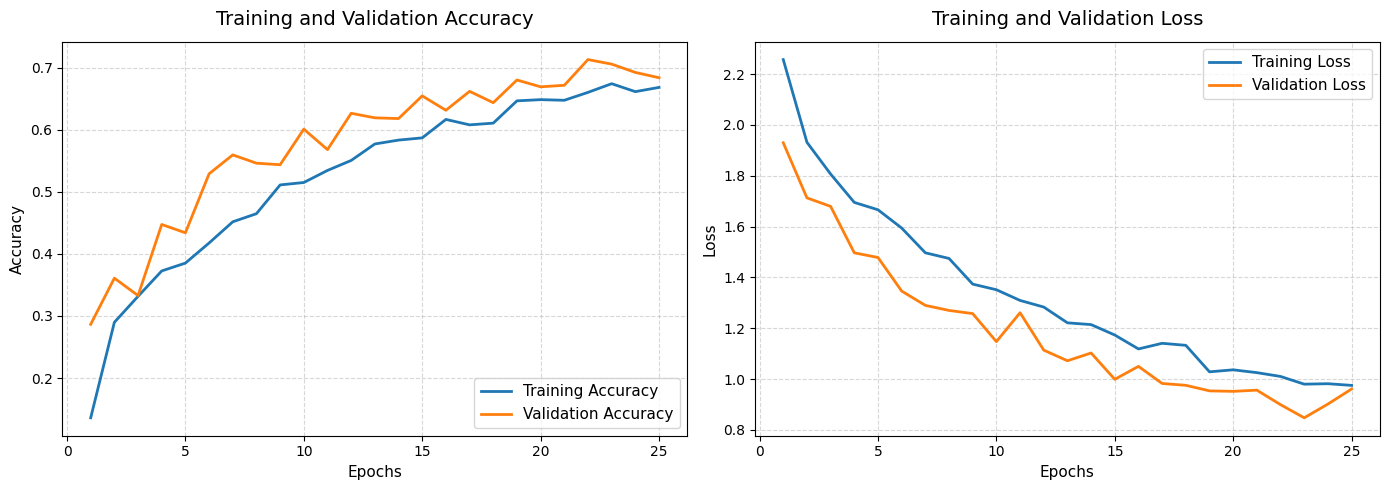

In [135]:
plot_learning_curves(history, EPOCHS)

## Testing del modelo

In [136]:
def evaluate_model(model, test_generator):
    """
    Evaluates the trained Keras model on the test dataset.

    Args:
        model (keras.Model): The trained Keras model.
        test_generator (ImageDataGenerator): Generator for test data.

    Returns:
        tuple: A tuple containing (test_loss, test_accuracy).
    """
    test_loss, test_accuracy = model.evaluate(test_generator)
    return (test_loss, test_accuracy)

In [137]:
# Evaluate the model using the test_generator
test_loss, test_accuracy = evaluate_model(model, test_generator)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.7091 - loss: 0.8714

Test Loss: 0.8714
Test Accuracy: 0.7091


### Gráfica de comparación training vs validation vs loss

In [138]:
def plot_final_accuracy_comparison(history, test_accuracy):
    """
    Generates a bar plot to compare the final Accuracy
    of the three stages: Training, Validation, and Test.

    Args:
        history (keras.callbacks.History): The history object returned from model.fit().
        test_accuracy (float): The accuracy obtained on the test set.

    Returns:
        None: Displays the plot.
    """
    # Extract the last value of training and validation
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    # Plot data
    stages = ['Training', 'Validation', 'Test']
    vals = [final_train_acc, final_val_acc, test_accuracy]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    plt.figure(figsize=(8, 4))
    barras = plt.bar(stages, vals, color=colors, width=0.5, edgecolor='black', alpha=0.8)

    # Add exact numbers above each bar
    for barra in barras:
        alto = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width()/2,
            alto + 0.05,
            f'{alto:.2f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # Plot aesthetics
    plt.title('Accuracy of all the stages', fontsize=14, pad=20, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12)
    plt.ylim(0, 1.15) # Space upwards so text is not cut off
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Save in high quality for your methodological framework
    plt.tight_layout()
    plt.savefig('comparative_accuracy.png', dpi=300)
    plt.show()

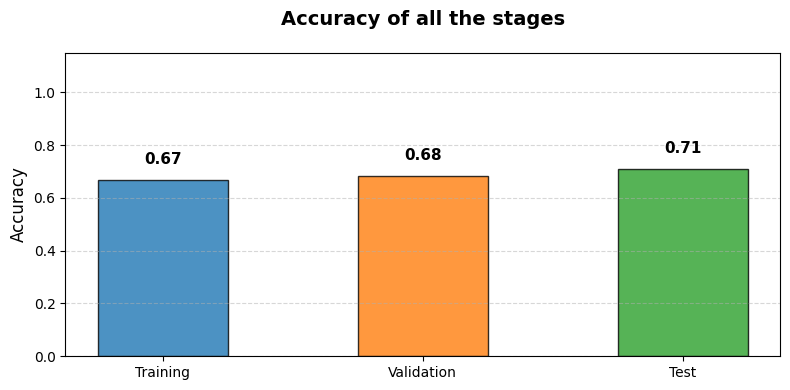

In [139]:
plot_final_accuracy_comparison(history, test_accuracy)

## Predecir frutas aleatorias

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step


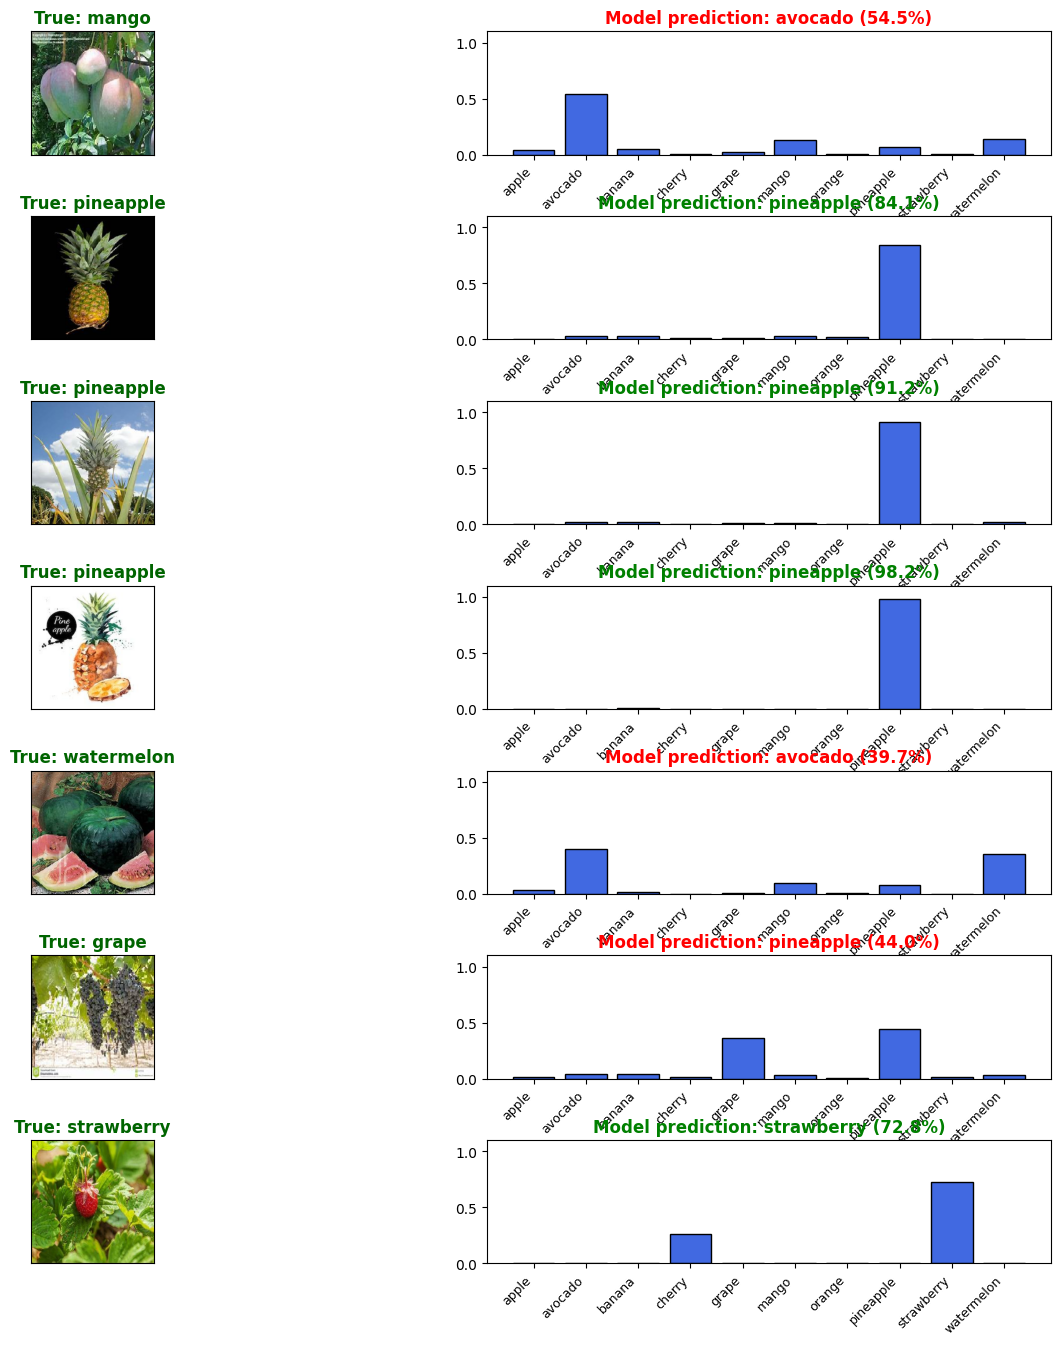

In [140]:
# Extract the names of the classes
class_names = list(test_generator.class_indices.keys())

# Random selection
random_test_images = []
random_test_labels = []
num_total_batches = len(test_generator)

# We are going to jump to 4 different random batches throughout the dataset
for _ in range(7):
    # Choose a random batch
    random_batch_idx = np.random.randint(0, num_total_batches)
    x_batch, y_batch = test_generator[random_batch_idx]

    # Choose a random image from that batch
    random_img_idx = np.random.randint(0, len(x_batch))

    random_test_images.append(x_batch[random_img_idx])
    random_test_labels.append(y_batch[random_img_idx])

# Convert lists into NumPy arrays
random_test_images = np.array(random_test_images)
random_test_labels = np.array(random_test_labels)

# The model predict
predictions = model.predict(random_test_images)

# Configure the visualization canvas
fig, axes = plt.subplots(7, 2, figsize=(16, 16))
fig.subplots_adjust(hspace=0.5, wspace=0.2)

for i, (prediction, image, label) in enumerate(zip(predictions, random_test_images, random_test_labels)):
    # Real image
    axes[i, 0].imshow(image)
    axes[i, 0].get_xaxis().set_visible(False)
    axes[i, 0].get_yaxis().set_visible(False)

    true_class_idx = np.argmax(label)
    #true_class_name = true_class_idx
    true_class_name = class_names[true_class_idx]
    axes[i, 0].set_title(f'True: {true_class_name}', fontsize=12, color='darkgreen', fontweight='bold')

    # Categorical distribution
    axes[i, 1].bar(np.arange(len(prediction)), prediction, color='royalblue', edgecolor='black')
    axes[i, 1].set_xticks(np.arange(len(prediction)))
    axes[i, 1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    axes[i, 1].set_ylim(0, 1.1)

    pred_class_idx = np.argmax(prediction)
    pred_class_name = class_names[pred_class_idx]
    confidence_score = prediction[pred_class_idx] * 100

    title_color = 'green' if pred_class_idx == true_class_idx else 'red'

    axes[i, 1].set_title(
        f"Model prediction: {pred_class_name} ({confidence_score:.1f}%)",
        color=title_color,
        fontweight='bold'
    )

plt.show()

In [141]:
def predict_model_data(model, test_generator):
    """
    Makes predictions using the trained model on the test generator and extracts true and predicted labels.

    Args:
        model (keras.Model): The trained Keras model.
        test_generator (ImageDataGenerator): Generator for test data.

    Returns:
        tuple: A tuple containing (y_true, y_pred).
               y_true (np.array): True labels.
               y_pred (np.array): Predicted labels.
    """
    predictions = model.predict(test_generator, verbose=1)

    # Convert probabilities to the index of the class with the highest value
    y_pred = np.argmax(predictions, axis=1)

    # Get true labels and category names directly from the generator
    y_true = test_generator.classes
    return (y_true, y_pred)

In [142]:
def plot_global_binary_confusion_matrix(y_true, y_pred):
    """
    Calculates and plots the global confusion matrix (2x2) oriented with
    Positives in the first row/column and Negatives in the second (image order 1).

    Args:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted labels.

    Returns:
        None: Displays the plot.
    """
    # Get individual matrices for each of the classes
    mcm = multilabel_confusion_matrix(y_true, y_pred)

    tn = mcm[:, 0, 0].sum()
    fp = mcm[:, 0, 1].sum()
    fn = mcm[:, 1, 0].sum()
    tp = mcm[:, 1, 1].sum()

    global_cm = np.array([[tp, fn],
                          [fp, tn]])

    # Create dynamic texts
    labels = np.array([
        [f"True positives\n{tp:,}", f"False negatives\n{fn:,}"],
        [f"False positives\n{fp:,}", f"True negatives\n{tn:,}"]
    ])

    # Design the plot with axis names
    plt.figure(figsize=(8, 7))
    sns.heatmap(
        global_cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=["Predicted Positive", "Predicted Negative"],
        yticklabels=["Actually Positive", "Actually Negative"]
    )

    # Title and axis aesthetics
    plt.title("General confusion matrix", fontsize=14, pad=20, fontweight='bold')
    plt.ylabel("Actual Label", fontsize=12, labelpad=10)
    plt.xlabel("Predicted Label", fontsize=12, labelpad=10)
    plt.tight_layout()

    plt.savefig('matrix_confusion_global.png', dpi=300)
    plt.show()

In [143]:
def plot_custom_confusion_matrix(y_true, y_pred, class_names):
    """
    Calculates and visually plots the confusion matrix for multiclass classification.

    Args:
        y_true (np.array): True labels.
        y_pred (np.array): Predicted labels.
        class_names (list): List of class names.

    Returns:
        None: Displays the plot.
    """
    cm = confusion_matrix(y_true, y_pred)

    # Configure the plot
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    # Plot configurations
    plt.title('Confusion Matrix - Fruit Classification', fontsize=16, pad=20)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    plt.savefig('confusion_matrix_classes.png', dpi=300)
    plt.show()

In [144]:
y_true, y_pred = predict_model_data(model, test_generator)

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step


## Matriz de confusión general

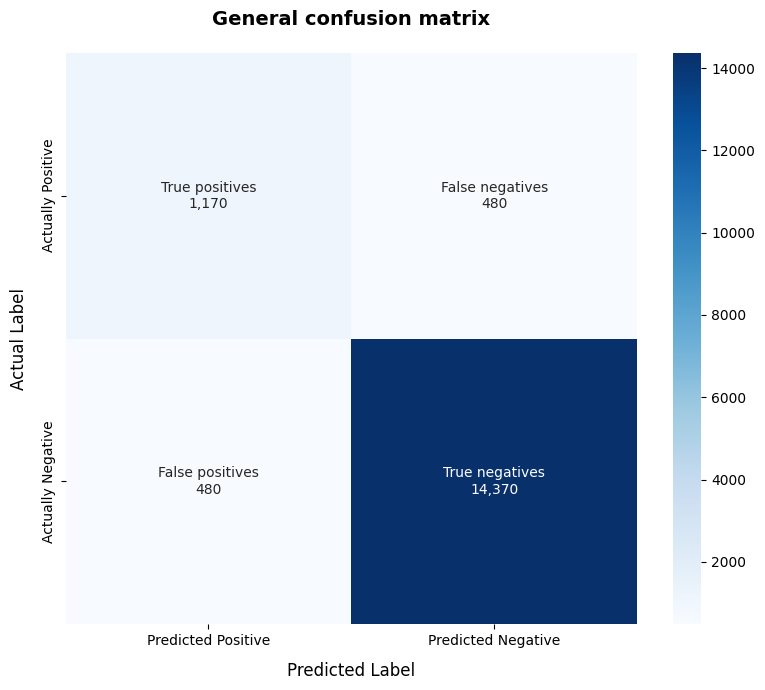

In [145]:
plot_global_binary_confusion_matrix(y_true, y_pred)

In [146]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='micro')
recall = recall_score(y_true, y_pred, average='micro')
f1 = f1_score(y_true, y_pred, average='micro')
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.7090909090909091
Precision: 0.7090909090909091
Recall: 0.7090909090909091
F1 Score: 0.7090909090909091


## Matriz de confusión por clases

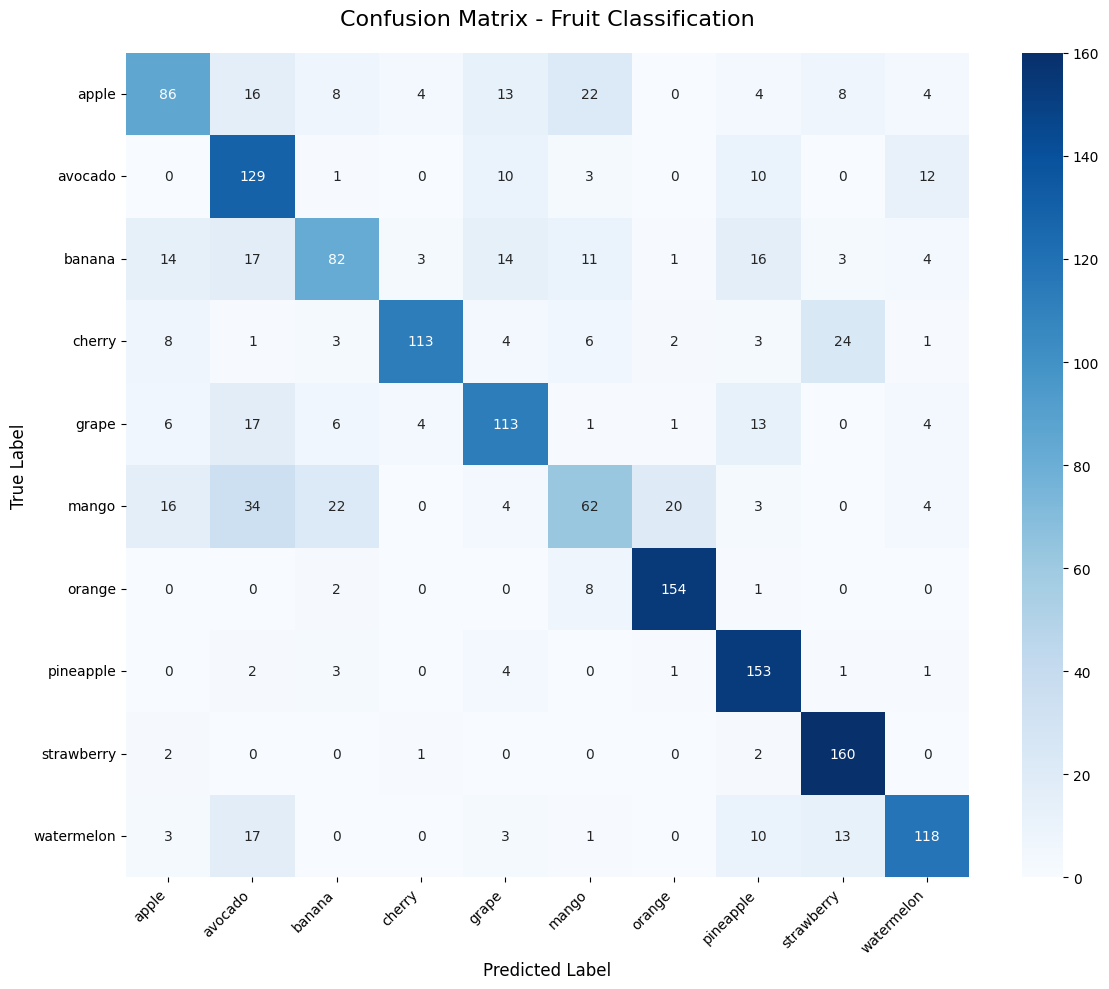

In [147]:
plot_custom_confusion_matrix(y_true, y_pred, class_names)

In [148]:
model.save('model.keras')

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab import files
from IPython.display import display, HTML
import io

# Preporcess the image
def preprocess_image(img_path, target_size):
    """
    Loads and preprocesses an image to match training conditions.
    Returns the raw PIL image (for display) and the model-ready array.
    """
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array

# Display the result in a chart
def show_prediction(img_pil, predictions, class_names, top_n=5):
    """
    Displays the image alongside a horizontal bar chart of the
    top-N predicted classes.
    """
    top_n = min(top_n, len(class_names))
    top_indices = np.argsort(predictions[0])[::-1][:top_n]
    top_probs = predictions[0][top_indices]
    top_labels = [class_names[i] for i in top_indices]

    predicted_class = top_labels[0]
    confidence = top_probs[0] * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#1a1a2e')

    # ── Left panel: uploaded image ─────────────────────────
    axes[0].imshow(img_pil)
    axes[0].set_title(
        f"Predicted: {predicted_class}\nConfidence: {confidence:.1f}%",
        fontsize=14, fontweight='bold', color='white', pad=12
    )
    axes[0].axis('off')
    axes[0].set_facecolor('#1a1a2e')

    # ── Right panel: probability bar chart ────────────────
    colors = ['#00d4aa' if i == 0 else '#4a5568' for i in range(top_n)]
    bars = axes[1].barh(
        range(top_n), top_probs * 100,
        color=colors, edgecolor='none', height=0.55
    )
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels(top_labels, fontsize=12, color='white')
    axes[1].set_xlabel('Probability (%)', fontsize=11, color='#a0aec0')
    axes[1].set_title('Top Predictions', fontsize=14, fontweight='bold', color='white', pad=12)
    axes[1].set_xlim(0, 110)
    axes[1].invert_yaxis()
    axes[1].set_facecolor('#16213e')
    axes[1].tick_params(colors='#a0aec0')
    axes[1].spines[:].set_visible(False)

    # Percentage labels on bars
    for bar, prob in zip(bars, top_probs):
        axes[1].text(
            bar.get_width() + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f'{prob*100:.1f}%',
            va='center', ha='left',
            fontsize=11, color='white', fontweight='bold'
        )

    plt.tight_layout(pad=2)
    plt.savefig('last_prediction.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Result → {predicted_class} ({confidence:.2f}% confidence)")

# Main loop
def run_classifier(model, class_names):
    """
    Interactively uploads and classifies images in a loop.
    The user clicks 'Cancel' in the file picker to stop.
    """
    display(HTML("""
    <div style="
        background: linear-gradient(135deg, #1a1a2e, #16213e);
        border: 1px solid #00d4aa;
        border-radius: 10px;
        padding: 16px 20px;
        color: white;
        font-family: monospace;
        font-size: 14px;
        margin-bottom: 12px;
    ">
        <b>Fruit Classifier</b> — Upload any fruit image to classify it.<br>
    </div>
    """))

    round_number = 1
    while True:
        try:
            uploaded = files.upload()
        except Exception:
            print("Upload cancelled.")
            break

        if not uploaded:
            print("No file selected.")
            break

        for filename, content in uploaded.items():
            # Save bytes to a temp file so Keras can open it
            tmp_path = f"/tmp/{filename}"
            with open(tmp_path, 'wb') as f:
                f.write(content)

            img_pil, img_array = preprocess_image(tmp_path, INPUT_SHAPE[:2]) # Use INPUT_SHAPE dynamically
            predictions = model.predict(img_array, verbose=0)
            show_prediction(img_pil, predictions, class_names)

class_names = [
    'apple',
    'avocado',
    'banana',
    'cherry',
    'grape',
    'mango',
    'orange',
    'pineapple',
    'strawberry',
    'watermelon'
]
#model = load_model('model.keras')
#run_classifier(model, class_names)